In [12]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
#loadig dataset
df = pd.read_csv('../data/processed/ml_ready_data.csv')
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.shape, df.columns

((777600, 37),
 Index(['timestamp', 'operating_regime', 'reactor_id', 'ambient_temp_effect',
        'reactor_temp', 'reactor_pressure', 'feed_flow_rate',
        'coolant_flow_rate', 'agitator_speed_rpm', 'reaction_rate',
        'conversion_rate', 'selectivity', 'yield_pct', 'vibration_rms',
        'motor_current', 'power_consumption_kw', 'temp_setpoint',
        'pressure_setpoint', 'fault_type', 'efficiency_loss_pct',
        'time_to_fault_min', 'failure_risk', 'hour', 'dayofweek', 'month',
        'reactor_temp_rolling_mean_60', 'reactor_temp_rolling_std_60',
        'reactor_pressure_rolling_mean_60', 'reactor_pressure_rolling_std_60',
        'coolant_flow_rate_rolling_mean_60', 'coolant_flow_rate_rolling_std_60',
        'vibration_rms_rolling_mean_60', 'vibration_rms_rolling_std_60',
        'motor_current_rolling_mean_60', 'motor_current_rolling_std_60',
        'power_consumption_kw_rolling_mean_60',
        'power_consumption_kw_rolling_std_60'],
       dtype='object'))

In [4]:
#target
df["failure_risk"].value_counts(normalize=True) * 100

failure_risk
0    96.411908
1     3.588092
Name: proportion, dtype: float64

In [5]:
#important features for predictive model
feature_cols = [
    "ambient_temp_effect",
    "reactor_temp",
    "reactor_pressure",
    "feed_flow_rate",
    "coolant_flow_rate",
    "agitator_speed_rpm",
    "reaction_rate",
    "conversion_rate",
    "selectivity",
    "yield_pct",
    "vibration_rms",
    "motor_current",
    "power_consumption_kw",
    "temp_setpoint",
    "pressure_setpoint",
    "hour",
    "dayofweek",
    "month"
]

In [6]:
#input and output variables
X = df[feature_cols].copy()
y = df["failure_risk"].copy()

X.shape, y.shape

((777600, 18), (777600,))

In [7]:
#check for missing values
X.isna().sum().sort_values(ascending=False)

ambient_temp_effect     0
reactor_temp            0
reactor_pressure        0
feed_flow_rate          0
coolant_flow_rate       0
agitator_speed_rpm      0
reaction_rate           0
conversion_rate         0
selectivity             0
yield_pct               0
vibration_rms           0
motor_current           0
power_consumption_kw    0
temp_setpoint           0
pressure_setpoint       0
hour                    0
dayofweek               0
month                   0
dtype: int64

In [8]:
#split data into train and test sets
df_model = df.sort_values("timestamp").copy()

split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df["failure_risk"]

X_test = test_df[feature_cols]
y_test = test_df["failure_risk"]

#print shapes and values
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


(622080, 18) (155520, 18)
failure_risk
0    0.963207
1    0.036793
Name: proportion, dtype: float64
failure_risk
0    0.967766
1    0.032234
Name: proportion, dtype: float64


In [9]:
#logistic regression model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)
y_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    150507
           1       0.67      0.86      0.75      5013

    accuracy                           0.98    155520
   macro avg       0.83      0.92      0.87    155520
weighted avg       0.98      0.98      0.98    155520

ROC-AUC: 0.9699773221196843
[[148354   2153]
 [   693   4320]]


In [10]:
#random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    150507
           1       0.98      0.29      0.44      5013

    accuracy                           0.98    155520
   macro avg       0.98      0.64      0.72    155520
weighted avg       0.98      0.98      0.97    155520

ROC-AUC: 0.9145903357059416
[[150485     22]
 [  3577   1436]]


The Random Forest model was used as a nonlinear baseline because industrial sensor behavior may contain nonlinear interactions between temperature, pressure, flow, vibration, and power consumption. Feature importance was extracted to identify which process variables contributed most to predicted failure risk.

In [11]:
#compare 2 models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "precision": precision_score(y_test, y_pred_lr),
        "recall": recall_score(y_test, y_pred_lr),
        "f1": f1_score(y_test, y_pred_lr),
        "roc_auc": roc_auc_score(y_test, y_proba_lr)
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "precision": precision_score(y_test, y_pred_rf),
        "recall": recall_score(y_test, y_pred_rf),
        "f1": f1_score(y_test, y_pred_rf),
        "roc_auc": roc_auc_score(y_test, y_proba_rf)
    }
])

results

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.981700,0.667388,0.861759,0.752220,0.969977
1,Random Forest,0.976858,0.984911,0.286455,0.443826,0.914590


Because the failure class is imbalanced, accuracy alone is not sufficient. The most important evaluation metrics are recall, F1-score, and ROC-AUC, especially for the failure class.

In [12]:
#save results to csv
results.to_csv("../outputs/results/rg_rf_model_comparison.csv", index=False)

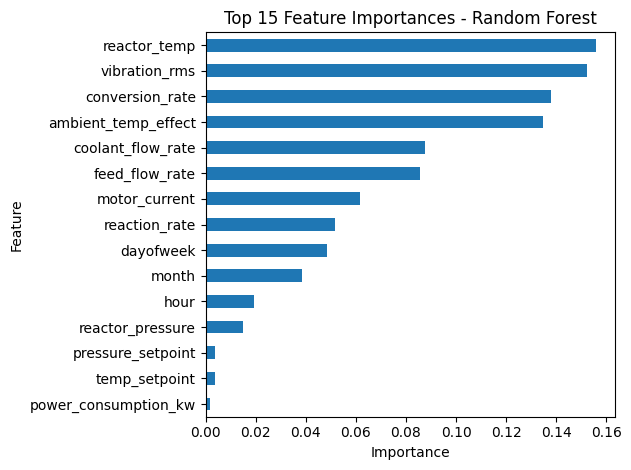

In [13]:
#plotting model comparison
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

#feature_importance.head(15)
feature_importance.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/figures/rf_feature_importance.png")
plt.show()

In [14]:
feature_importance.to_csv("../outputs/results/rg_rf_feature_importance.csv", index=False)

In [15]:
test_predictions = test_df[[
    "timestamp",
    "reactor_id",
    "operating_regime",
    "fault_type",
    "failure_risk",
    "efficiency_loss_pct",
    "time_to_fault_min"
]].copy()

test_predictions["predicted_failure_risk"] = y_proba_rf

test_predictions.to_csv(
    "../outputs/results/rg_rf_failure_risk_predictions.csv",
    index=False
)

The predicted failure probabilities are saved for later use in the maintenance optimization model, where reactors with higher predicted risk will be prioritized under technician-capacity and downtime constraints.

In [16]:
base_features = [
    "ambient_temp_effect",
    "reactor_temp",
    "reactor_pressure",
    "feed_flow_rate",
    "coolant_flow_rate",
    "agitator_speed_rpm",
    "reaction_rate",
    "conversion_rate",
    "selectivity",
    "yield_pct",
    "vibration_rms",
    "motor_current",
    "power_consumption_kw",
    "temp_setpoint",
    "pressure_setpoint",
    "hour",
    "dayofweek",
    "month"
]

rolling_features = [
    col for col in df.columns
    if "rolling_mean_60" in col or "rolling_std_60" in col
]

feature_cols = base_features + rolling_features

len(feature_cols), feature_cols[:10]

(30,
 ['ambient_temp_effect',
  'reactor_temp',
  'reactor_pressure',
  'feed_flow_rate',
  'coolant_flow_rate',
  'agitator_speed_rpm',
  'reaction_rate',
  'conversion_rate',
  'selectivity',
  'yield_pct'])

These rolling features are important because faults develop gradually. A 60-minute rolling mean or standard deviation can capture sensor instability before failure.

In [20]:
#df.head(5)
df_model = pd.get_dummies(
    df,
    columns=["operating_regime"],
    drop_first=True
)
feature_cols = feature_cols + ["operating_regime_B"]

In [21]:
df_model = df_model.sort_values("timestamp").copy()

split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index]
test_df = df_model.iloc[split_index:]

X_train = train_df[feature_cols]
y_train = train_df["failure_risk"]

X_test = test_df[feature_cols]
y_test = test_df["failure_risk"]

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train target distribution:
failure_risk
0    0.963207
1    0.036793
Name: proportion, dtype: float64
Test target distribution:
failure_risk
0    0.967766
1    0.032234
Name: proportion, dtype: float64


In [22]:
#improved random forest model 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_improved = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train, y_train)

y_pred_rf = rf_improved.predict(X_test)
y_proba_rf = rf_improved.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    150507
           1       1.00      0.60      0.75      5013

    accuracy                           0.99    155520
   macro avg       0.99      0.80      0.87    155520
weighted avg       0.99      0.99      0.99    155520

ROC-AUC: 0.9475642373328983
[[150507      0]
 [  1984   3029]]


In [ ]:
#manually adjust classification threshold
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,threshold,precision,recall,f1
0,0.2,0.958831,0.785159,0.863347
1,0.3,0.996020,0.748853,0.854931
2,0.4,0.999711,0.690405,0.816755
3,0.5,1.000000,0.604229,0.753295
4,0.6,1.000000,0.468382,0.637957


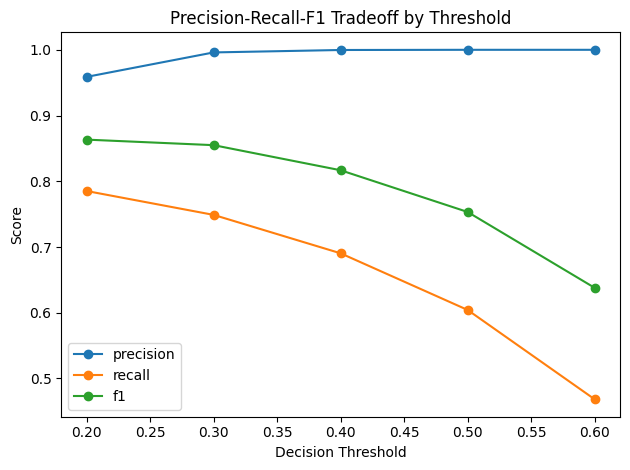

In [24]:
threshold_results.plot(
    x="threshold",
    y=["precision", "recall", "f1"],
    marker="o"
)

plt.title("Precision-Recall-F1 Tradeoff by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("../outputs/figures/day4_threshold_tradeoff.png")
plt.show()

In predictive maintenance, the decision threshold should reflect the cost of missing a failure. A lower threshold increases recall and detects more potential failures, but may also increase false alarms. The selected threshold should balance maintenance capacity and failure-prevention goals.

In [25]:
#example of adjusting threshold to 0.3
selected_threshold = 0.3
y_pred_selected = (y_proba_rf >= selected_threshold).astype(int)

print(classification_report(y_test, y_pred_selected))
print(confusion_matrix(y_test, y_pred_selected))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    150507
           1       1.00      0.75      0.85      5013

    accuracy                           0.99    155520
   macro avg       0.99      0.87      0.93    155520
weighted avg       0.99      0.99      0.99    155520

[[150492     15]
 [  1259   3754]]


In [26]:
#important features for predictive model
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_improved.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
18,reactor_temp_rolling_mean_60,0.133360
7,conversion_rate,0.123466
22,coolant_flow_rate_rolling_mean_60,0.096285
0,ambient_temp_effect,0.089660
3,feed_flow_rate,0.083775
24,vibration_rms_rolling_mean_60,0.078524
1,reactor_temp,0.064765
26,motor_current_rolling_mean_60,0.053608
10,vibration_rms,0.043562
4,coolant_flow_rate,0.033975


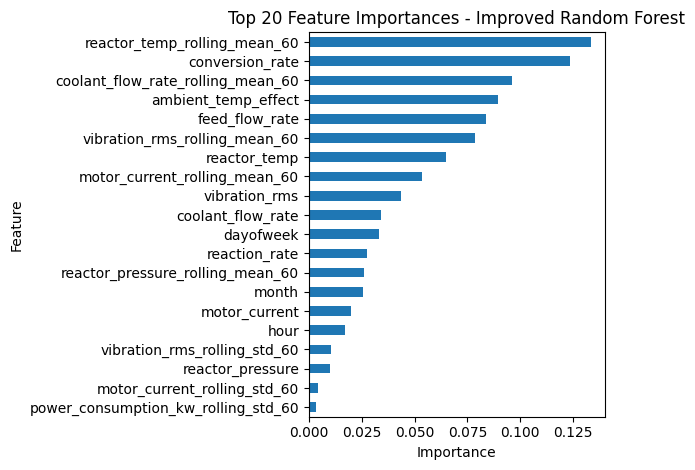

In [30]:
feature_importance.head(20).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top 20 Feature Importances - Improved Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/figures/rf_feature_importance.png")
plt.show()

In [29]:
feature_importance.to_csv(
    "../outputs/results/rf_feature_importance.csv",
    index=False
)

In [32]:
#reactor-level predicted risk
test_predictions = test_df[[
    "timestamp",
    "reactor_id",
    "fault_type",
    "failure_risk",
    "efficiency_loss_pct",
    "time_to_fault_min"
]].copy()

test_predictions["predicted_failure_risk"] = y_proba_rf
test_predictions["predicted_failure_label"] = y_pred_selected

test_predictions.to_csv(
    "../outputs/results/failure_risk_predictions.csv",
    index=False
)

In [33]:
reactor_risk = test_predictions.groupby("reactor_id").agg(
    avg_predicted_failure_risk=("predicted_failure_risk", "mean"),
    max_predicted_failure_risk=("predicted_failure_risk", "max"),
    predicted_failure_count=("predicted_failure_label", "sum"),
    actual_failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    avg_time_to_fault=("time_to_fault_min", "mean")
).sort_values("avg_predicted_failure_risk", ascending=False)

reactor_risk

,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,avg_time_to_fault
reactor_id,,,,,,
B_R3,0.116935,0.986867,1363,0.055710,0.929208,303.606366
A_R2,0.065886,0.782827,1460,0.070139,1.052083,205.204000
A_R3,0.036498,0.582024,774,0.042052,0.631173,675.832879
A_R1,0.030990,0.146220,0,0.000000,0.000000,0.000000
B_R1,0.028982,0.784873,162,0.011883,0.178241,64.752140
B_R2,0.022272,0.476758,10,0.013619,0.203799,230.909735


In [34]:
reactor_risk.to_csv(
    "../outputs/results/reactor_predicted_risk_summary.csv"
)

The improved Random Forest model uses both raw sensor readings and rolling time-window features to predict reactor failure risk. Rolling features are useful because industrial faults often develop gradually through changes in sensor trends and variability. A threshold analysis was performed to compare precision, recall, and F1-score under different maintenance decision thresholds. Finally, predicted failure probabilities were aggregated at the reactor level to prepare inputs for the maintenance optimization model.

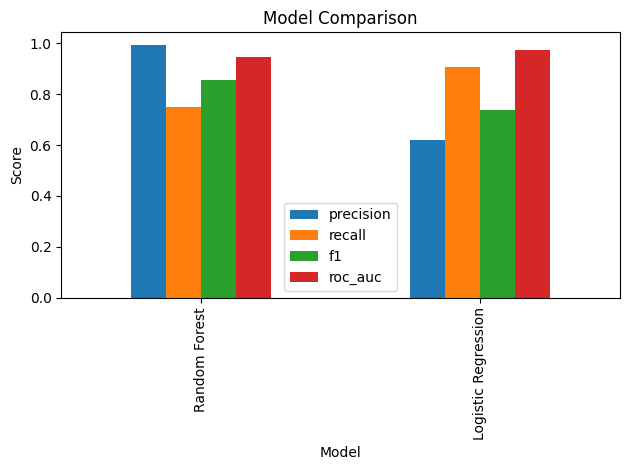

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.read_csv("../outputs/results/model_comparison.csv")

model_comparison.plot(
    x="model",
    y=["precision", "recall", "f1", "roc_auc"],
    kind="bar"
)

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison.png")
plt.show()

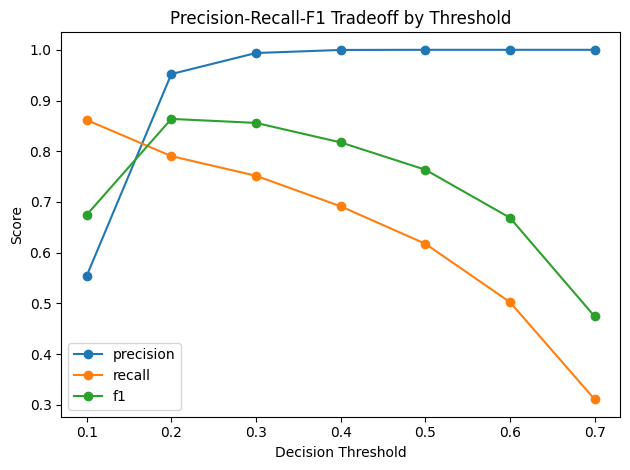

In [ ]:

threshold_results = pd.read_csv("../outputs/results/threshold_analysis.csv")


threshold_results.plot(
    x="threshold",
    y=["precision", "recall", "f1"],
    marker="o"
)

plt.title("Precision-Recall-F1 Tradeoff by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("../outputs/figures/threshold_tradeoff.png")
plt.show()

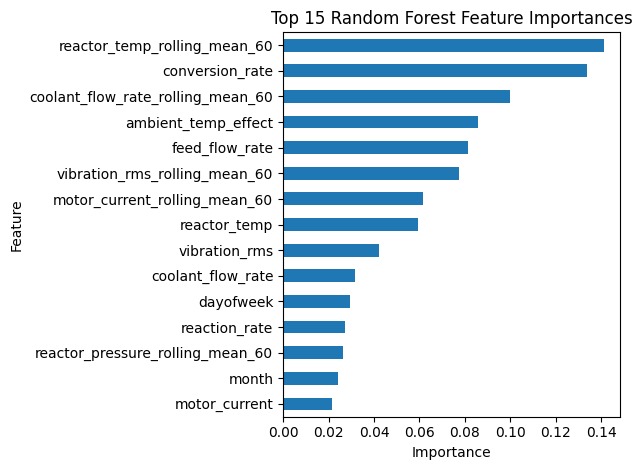

In [9]:
feature_importance = pd.read_csv("../outputs/results/rf_feature_importance.csv")
feature_importance.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/figures/rf_feature_importance.png")
plt.show()

model validation
data leakage check
validation strategy
reactor-level testing
confusion matrix interpretation

In [14]:
base_features = [
    "ambient_temp_effect",
    "reactor_temp",
    "reactor_pressure",
    "feed_flow_rate",
    "coolant_flow_rate",
    "agitator_speed_rpm",
    "reaction_rate",
    "conversion_rate",
    "selectivity",
    "yield_pct",
    "vibration_rms",
    "motor_current",
    "power_consumption_kw",
    "temp_setpoint",
    "pressure_setpoint",
    "hour",
    "dayofweek",
    "month"
]

rolling_features = [
    col for col in df.columns
    if "rolling_mean_60" in col or "rolling_std_60" in col
]

feature_cols = [
    col for col in base_features + rolling_features
    if col in df.columns
]

feature_cols

['ambient_temp_effect',
 'reactor_temp',
 'reactor_pressure',
 'feed_flow_rate',
 'coolant_flow_rate',
 'agitator_speed_rpm',
 'reaction_rate',
 'conversion_rate',
 'selectivity',
 'yield_pct',
 'vibration_rms',
 'motor_current',
 'power_consumption_kw',
 'temp_setpoint',
 'pressure_setpoint',
 'hour',
 'dayofweek',
 'month',
 'reactor_temp_rolling_mean_60',
 'reactor_temp_rolling_std_60',
 'reactor_pressure_rolling_mean_60',
 'reactor_pressure_rolling_std_60',
 'coolant_flow_rate_rolling_mean_60',
 'coolant_flow_rate_rolling_std_60',
 'vibration_rms_rolling_mean_60',
 'vibration_rms_rolling_std_60',
 'motor_current_rolling_mean_60',
 'motor_current_rolling_std_60',
 'power_consumption_kw_rolling_mean_60',
 'power_consumption_kw_rolling_std_60']

In [15]:
target_related_cols = [
    "fault_type",
    "failure_risk",
    "efficiency_loss_pct",
    "time_to_fault_min",
    "predicted_failure_risk",
    "predicted_failure_label"
]

used_leakage_cols = [col for col in feature_cols if col in target_related_cols]

used_leakage_cols

[]

Target-related columns such as fault_type, efficiency_loss_pct, time_to_fault_min, and failure_risk were excluded from the feature set to avoid data leakage. The model only uses sensor readings, process variables, time features, and rolling sensor statistics.


In [17]:
feature_cols

feature_list = pd.DataFrame({"feature": feature_cols})

feature_list.to_csv(
    "../outputs/results/final_ml_feature_list.csv",
    index=False
)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

reactor_validation_results = []

reactors = df["reactor_id"].unique()

for test_reactor in reactors:
    train_df = df[df["reactor_id"] != test_reactor].copy()
    test_df = df[df["reactor_id"] == test_reactor].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["failure_risk"]

    X_test = test_df[feature_cols]
    y_test = test_df["failure_risk"]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.30).astype(int)

    reactor_validation_results.append({
        "test_reactor": test_reactor,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "actual_failure_rate": y_test.mean()
    })

reactor_validation_results = pd.DataFrame(reactor_validation_results)

reactor_validation_results

,test_reactor,accuracy,precision,recall,f1,roc_auc,actual_failure_rate
0,A_R1,0.171273,0.053365,0.955840,0.101087,0.712752,0.048750
1,A_R2,0.876119,0.113538,0.639760,0.192851,0.812022,0.023133
2,A_R3,0.975772,0.989809,0.332193,0.497439,0.904215,0.036096
3,B_R1,0.951019,0.471722,0.775482,0.586611,0.911679,0.044815
4,B_R2,0.989722,0.814607,0.591354,0.685255,0.873473,0.018920
5,B_R3,0.045795,0.043670,1.000000,0.083685,0.676936,0.043573


In [19]:
reactor_validation_results.to_csv(
    "../outputs/results/leave_one_reactor_out_validation.csv",
    index=False
)

Leave-one-reactor-out validation tests whether the model can generalize to an unseen reactor. This is more realistic than only testing on randomly mixed observations because industrial predictive maintenance models often need to work across different assets.

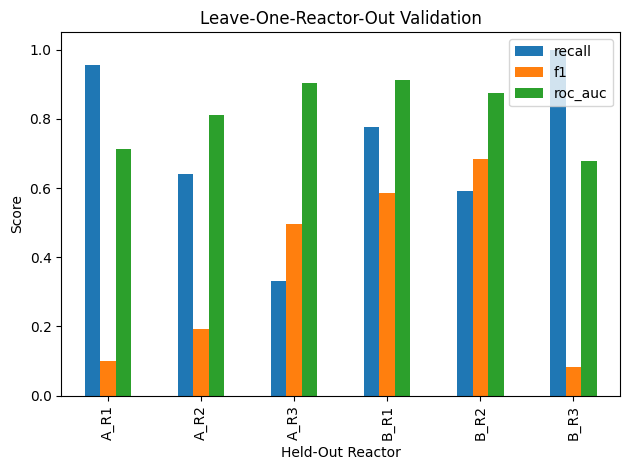

In [20]:
reactor_validation_results.plot(
    x="test_reactor",
    y=["recall", "f1", "roc_auc"],
    kind="bar"
)

plt.title("Leave-One-Reactor-Out Validation")
plt.xlabel("Held-Out Reactor")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("../outputs/figures/leave_one_reactor_out_validation.png")
plt.show()

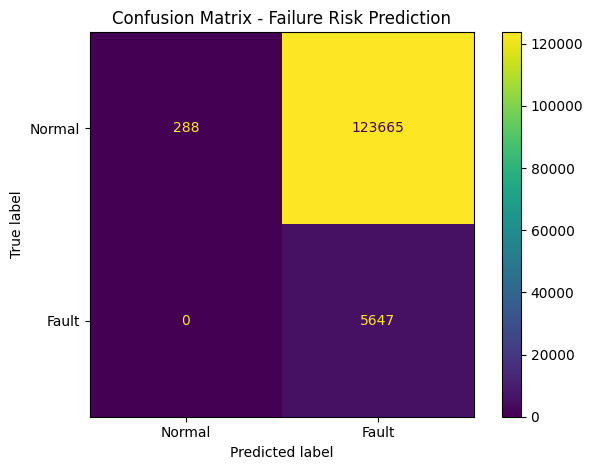

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fault"]
)

disp.plot()
plt.title("Confusion Matrix - Failure Risk Prediction")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_failure_prediction.png")
plt.show()

The confusion matrix shows how many normal and fault observations were correctly or incorrectly classified. In predictive maintenance, false negatives are especially important because they represent missed fault conditions.